# **Exploratory Data Analysis (EDA)**

Objective:
Explore the cleaned dataset to understand distributions, relationships, and patterns before performing business analysis.

# **Import  Libraries**

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# **Load the Clean Dataset**

In [ ]:
df = pd.read_csv("cleaned_road_accident.csv")

# **Dataset Overview**

In [ ]:
df.head()

,accident_id,city,state,latitude,longitude,date,time,hour,day_of_week,is_weekend,...,traffic_density,cause,accident_severity,vehicles_involved,casualties,is_peak_hour,festival,risk_score,severity_index,risk_quartile
0,0,Pune,Maharashtra,18.680826,73.93039,2023-10-22,5:00,5,Sunday,Weekend,...,high,weather,fatal,2,2,Non Peak Hour,No Festival,0.85,4,Q4
1,1,Mumbai,Maharashtra,18.817732,72.79085,2023-05-21,4:00,4,Sunday,Weekend,...,low,weather,major,4,3,Non Peak Hour,No Festival,0.10,12,Q1
2,2,Mumbai,Maharashtra,19.096890,72.81943,2024-07-10,13:00,13,Wednesday,Weekday,...,medium,weather,minor,1,1,Non Peak Hour,No Festival,0.45,1,Q2
3,3,Chandigarh,Punjab,30.787806,76.84750,2025-03-30,11:00,11,Sunday,Weekend,...,high,distraction,minor,5,2,Non Peak Hour,No Festival,0.65,10,Q4
4,4,Chennai,Tamil Nadu,12.965155,80.28331,2024-01-25,16:00,16,Thursday,Weekday,...,low,distraction,minor,2,1,Non Peak Hour,No Festival,0.10,2,Q1


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 26 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   accident_id        20000 non-null  int64  
 1   city               20000 non-null  object 
 2   state              20000 non-null  object 
 3   latitude           20000 non-null  float64
 4   longitude          20000 non-null  float64
 5   date               20000 non-null  object 
 6   time               20000 non-null  object 
 7   hour               20000 non-null  int64  
 8   day_of_week        20000 non-null  object 
 9   is_weekend         20000 non-null  object 
 10  road_type          20000 non-null  object 
 11  lanes              20000 non-null  int64  
 12  traffic_signal     20000 non-null  int64  
 13  weather            20000 non-null  object 
 14  visibility         20000 non-null  object 
 15  temperature        20000 non-null  int64  
 16  traffic_density    200

In [ ]:
df.shape

(20000, 26)

# **Descriptive Statistics**

**Numerical**

In [ ]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
accident_id,20000.0,9999.500000,5773.647028,0.000000,4999.750000,9999.500000,14999.250000,19999.00000
latitude,20000.0,20.389207,6.165791,12.800172,13.198653,18.812008,28.402467,30.79996
longitude,20000.0,78.173330,4.485967,72.700020,73.997977,77.297000,80.111087,88.49986
hour,20000.0,11.487200,6.945563,0.000000,5.000000,12.000000,18.000000,23.00000
lanes,20000.0,3.493950,1.705406,1.000000,2.000000,4.000000,5.000000,6.00000
traffic_signal,20000.0,0.499850,0.500012,0.000000,0.000000,0.000000,1.000000,1.00000
temperature,20000.0,27.579600,7.454746,15.000000,21.000000,28.000000,34.000000,40.00000
vehicles_involved,20000.0,2.992000,1.415534,1.000000,2.000000,3.000000,4.000000,5.00000
casualties,20000.0,1.726450,1.489104,0.000000,1.000000,1.000000,3.000000,5.00000
risk_score,20000.0,0.437585,0.218130,0.100000,0.250000,0.450000,0.600000,1.00000


**Categorical**

In [ ]:
df.describe(include='object').T

,count,unique,top,freq
city,20000,8,Chandigarh,2577
state,20000,7,Maharashtra,5009
date,20000,1201,2022-11-03,30
time,20000,24,2:00,888
day_of_week,20000,7,Monday,2966
is_weekend,20000,2,Weekday,14277
road_type,20000,3,urban,6745
weather,20000,3,clear,6690
visibility,20000,3,low,9987
traffic_density,20000,3,low,7067


# **Numerical Feature Distribution**

<Axes: xlabel='risk_score', ylabel='Count'>

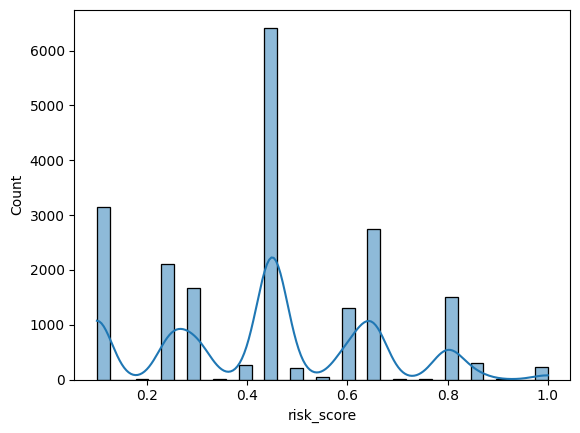

In [ ]:
sns.histplot(df['risk_score'],kde=True)

<Axes: xlabel='severity_index', ylabel='Count'>

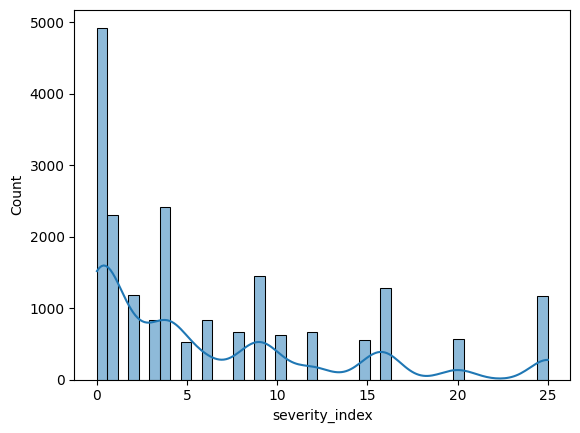

In [ ]:
sns.histplot(df['severity_index'],kde=True)

# **Categorical Feature Distribution**

In [ ]:
print(df['weather'].value_counts())
print('---------------------------')
print(df['accident_severity'].value_counts())
print('---------------------------')
print(df['cause'].value_counts())
print('---------------------------')
print(df['festival'].value_counts())

weather
clear    6690
rain     6677
fog      6633
Name: count, dtype: int64
---------------------------
accident_severity
minor    11025
major     5988
fatal     2987
Name: count, dtype: int64
---------------------------
cause
distraction      4026
overspeeding     4025
weather          3997
drunk driving    3978
poor road        3974
Name: count, dtype: int64
---------------------------
festival
No Festival    19885
Holi              38
Eid               34
Diwali            31
New Year          12
Name: count, dtype: int64


# **Correlation Analysis**

In [ ]:
numeric_df = df[[
    'severity_index',
    'temperature',
    'vehicles_involved',
    'casualties',
    'hour',
    'risk_score'
]]

corr_matrix = numeric_df.corr()
corr_matrix

,severity_index,temperature,vehicles_involved,casualties,hour,risk_score
severity_index,1.000000,-0.005669,0.685943,0.952437,-0.007225,0.092963
temperature,-0.005669,1.000000,-0.004479,-0.005842,-0.005982,-0.001885
vehicles_involved,0.685943,-0.004479,1.000000,0.550966,-0.004176,0.000642
casualties,0.952437,-0.005842,0.550966,1.000000,-0.004320,0.119954
hour,-0.007225,-0.005982,-0.004176,-0.004320,1.000000,0.122017
risk_score,0.092963,-0.001885,0.000642,0.119954,0.122017,1.000000


Text(0.5, 1.0, 'Correlation Matrix of Numerical Features')

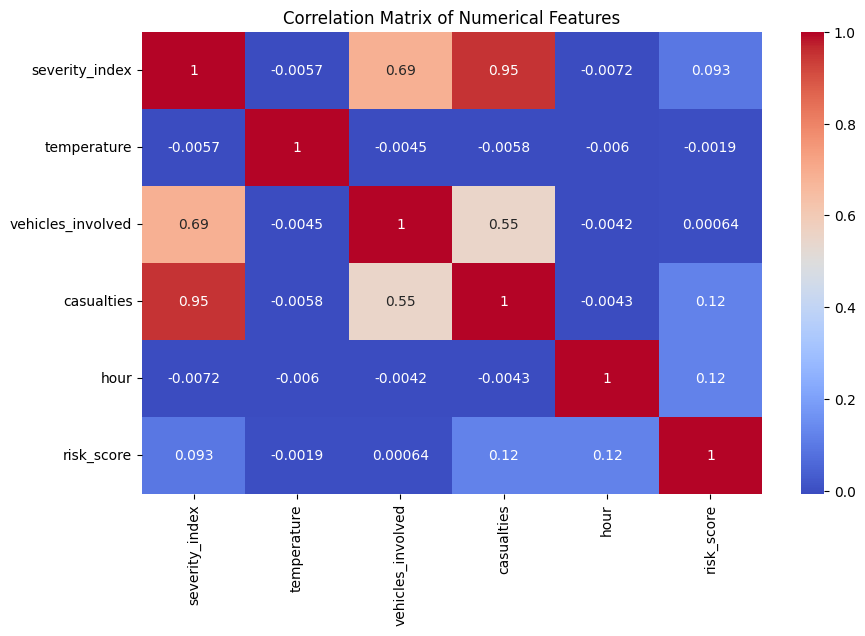

In [ ]:
plt.figure(figsize=(10,6))
sns.heatmap(
    corr_matrix,
    annot = True,
    cmap='coolwarm'
)
plt.title('Correlation Matrix of Numerical Features')

# **Outlier Detection**

<Axes: xlabel='risk_score'>

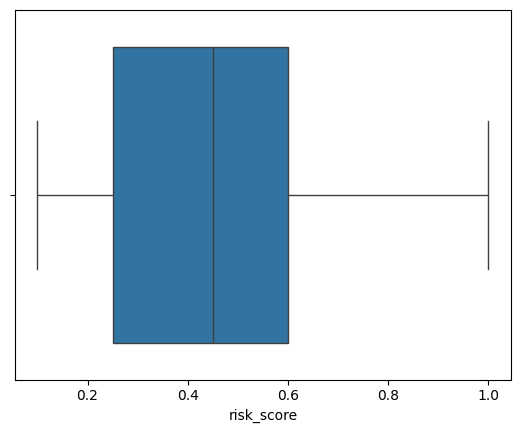

In [ ]:
sns.boxplot(x=df['risk_score']) # no outlier detect

<Axes: xlabel='severity_index'>

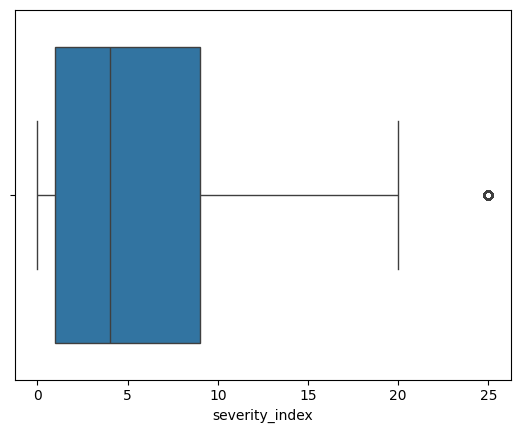

In [ ]:
sns.boxplot(x=df['severity_index']) # outlier detect when severity index = 25

**Relationship Between Variables**

<Axes: xlabel='risk_score', ylabel='severity_index'>

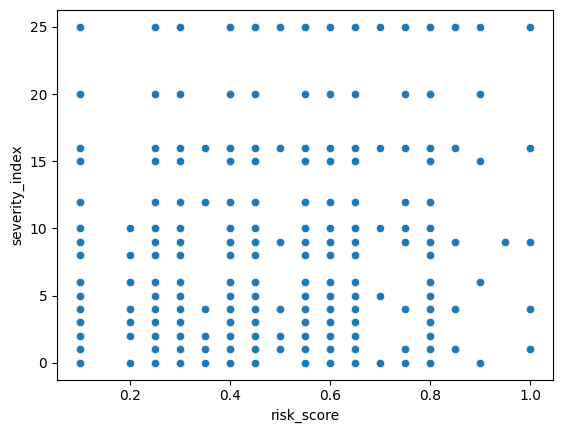

In [ ]:
sns.scatterplot(
    df,
    x='risk_score',
    y='severity_index'
)
# no strong relation

<Axes: xlabel='cause', ylabel='risk_score'>

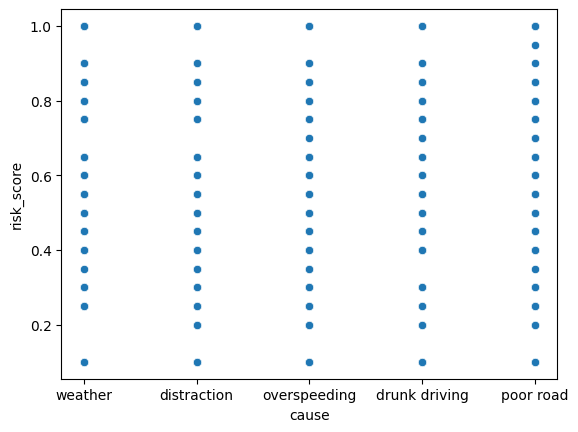

In [ ]:
sns.scatterplot(
    data=df,
    x='cause',
    y='risk_score'
)

## **Exploratory Data Analysis Summary**

- The exploratory data analysis (EDA) provided a comprehensive understanding of the cleaned road accident dataset before conducting detailed business analysis. The dataset contains a combination of numerical and categorical features covering accident location, date and time, weather conditions, traffic density, accident causes, severity, casualties, risk score, and engineered features such as Severity Index and Risk Quartile.

- Descriptive statistics highlighted the distribution, central tendency, and variability of numerical variables, while categorical analysis revealed the diversity of accident conditions across different states, cities, weather types, and severity levels. Correlation analysis indicated that accident severity and risk are influenced by multiple factors rather than a single variable. Outlier detection identified a small number of high-severity accident records, which were retained as they represent valid real-world events.

- Overall, the dataset is well-structured, consistent, and suitable for advanced analysis. The insights obtained during EDA establish a strong foundation for KPI analysis, business insights, data visualization, and interactive dashboard development in the subsequent notebooks.